#  Sales Prediction Using Advertising Spend

This notebook demonstrates a comprehensive machine learning workflow for predicting sales based on advertising spending across different channels (TV, Radio, Newspaper).

**Project Workflow:**
1. Data Loading & Exploration
2. Data Cleaning & Preprocessing  
3. Exploratory Data Analysis (EDA)
4. Model Training & Hyperparameter Tuning
5. Feature Engineering
6. Model Comparison & Evaluation

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error as mse
import kaggle
from kaggle.api.kaggle_api_extended import KaggleApi

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
## Step 1: Data Loading

# Download advertising dataset from Kaggle via API
api = KaggleApi()
api.authenticate()

handle = 'bumba5341/advertisingcsv'
api.dataset_download_files(handle, path='./', unzip=True)
print(" Dataset downloaded successfully")

Dataset URL: https://www.kaggle.com/datasets/bumba5341/advertisingcsv
 Dataset downloaded successfully


In [3]:
# Load and preview the data
advert = pd.read_csv('Advertising.csv')
print(f"Dataset shape: {advert.shape}\n")
advert.head()

Dataset shape: (200, 5)



,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Step 2: Data Exploration & Cleaning

In [4]:
# Display dataset information
print("Dataset Information:")
print(advert.info())
print('\n' + '='*70 + '\n')
print(f"Dataset Shape: {advert.shape}")
print('\n' + '='*70 + '\n')
print("Statistical Summary:")
advert.describe().T

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None


Dataset Shape: (200, 5)


Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,200.0,100.5000,57.879185,1.0,50.750,100.50,150.250,200.0
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,14.0225,5.217457,1.6,10.375,12.90,17.400,27.0


In [5]:
# Check for missing values and duplicates
print("Missing values:")
print(advert.isnull().sum())
print('\n' + '='*70 + '\n')

print(f"Duplicate rows: {advert.duplicated().sum()}")

Missing values:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64


Duplicate rows: 0


In [6]:
# Remove unnecessary columns and display cleaned data
print("Columns in dataset:")
print(advert.columns.tolist())

# Drop unnamed index column
advert = advert.drop('Unnamed: 0', axis=1, inplace=False)
print("\n Unnamed index column removed")
print(f"Cleaned dataset shape: {advert.shape}")

Columns in dataset:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

 Unnamed index column removed
Cleaned dataset shape: (200, 4)


## Step 3: Exploratory Data Analysis (EDA)

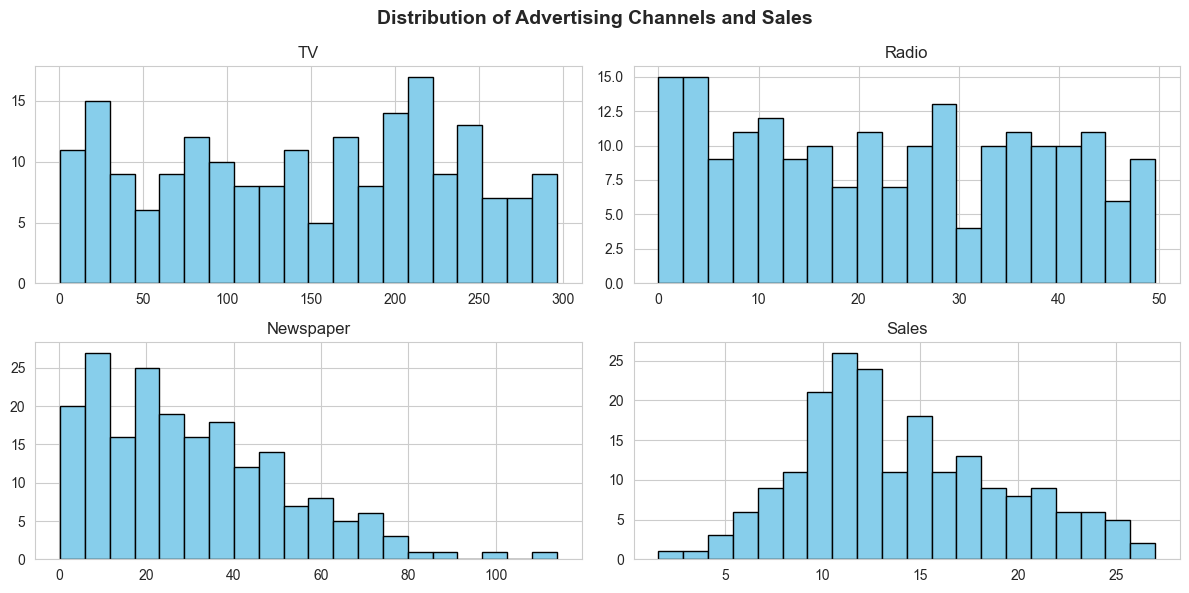

In [7]:
# Visualize distribution of advertising channels and sales
advert.hist(bins=20, figsize=(12, 6), color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Advertising Channels and Sales", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

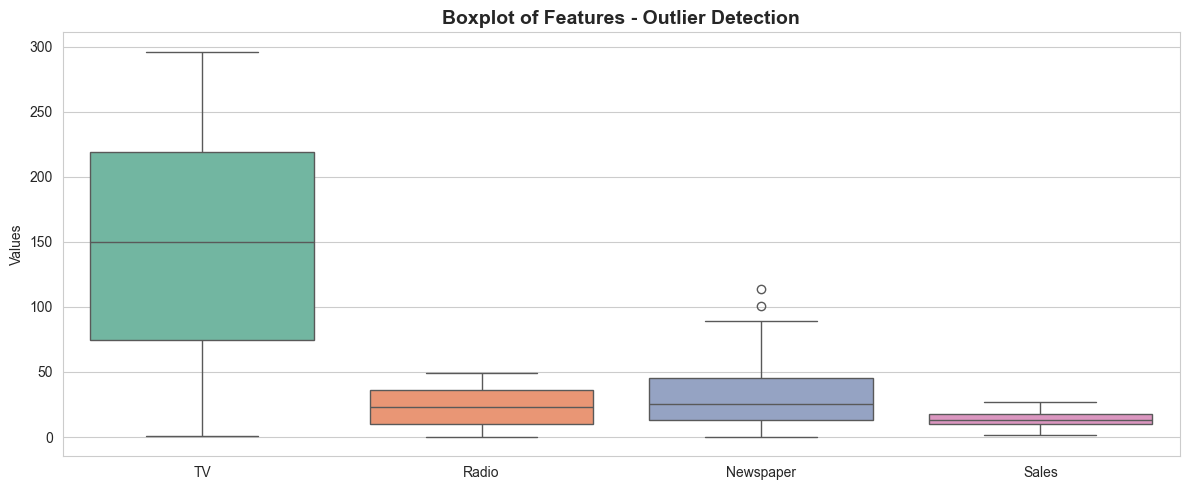

In [8]:
# Detect outliers using boxplots
plt.figure(figsize=(12, 5))
sns.boxplot(data=advert, palette="Set2")
plt.title("Boxplot of Features - Outlier Detection", fontsize=14, fontweight='bold')
plt.ylabel("Values")
plt.tight_layout()
plt.show()

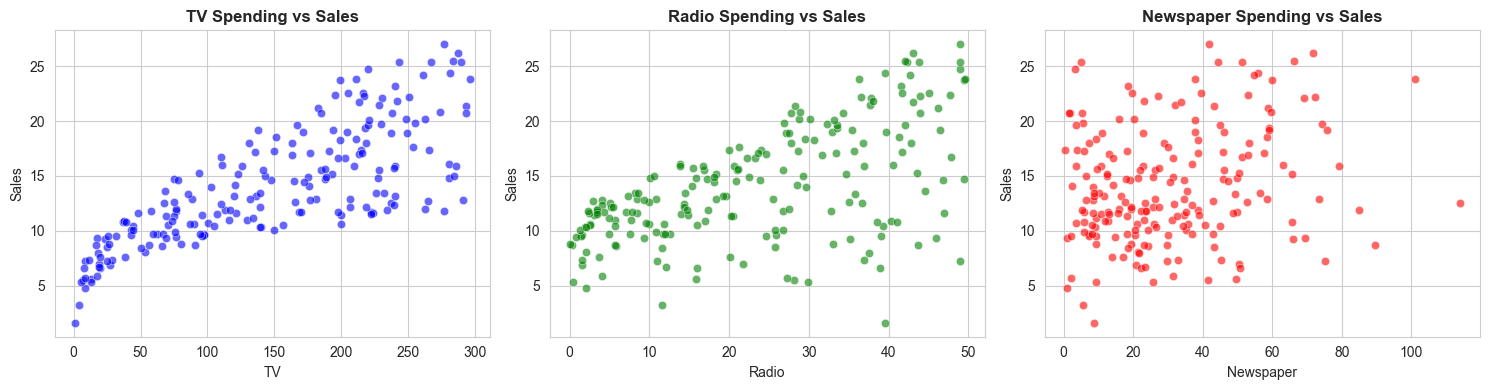

In [9]:
# Analyze relationships between advertising channels and sales
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(x='TV', y='Sales', data=advert, ax=axs[0], color='blue', alpha=0.6)
sns.scatterplot(x='Radio', y='Sales', data=advert, ax=axs[1], color='green', alpha=0.6)
sns.scatterplot(x='Newspaper', y='Sales', data=advert, ax=axs[2], color='red', alpha=0.6)

axs[0].set_title("TV Spending vs Sales", fontweight='bold')
axs[1].set_title("Radio Spending vs Sales", fontweight='bold')
axs[2].set_title("Newspaper Spending vs Sales", fontweight='bold')
plt.tight_layout()
plt.show()

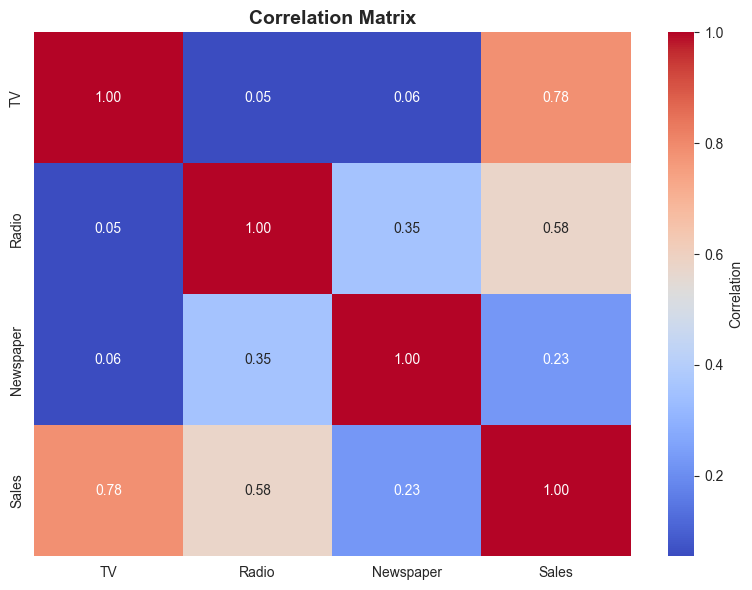

Correlation with Sales:
Sales        1.000000
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


In [10]:
# Correlation analysis
plt.figure(figsize=(8, 6))
correlation_matrix = advert.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar_kws={'label': 'Correlation'})
plt.title("Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlation with Sales:")
print(correlation_matrix['Sales'].sort_values(ascending=False))

### Sales Distribution by Advertising Channel Strength

C:\Users\levie\AppData\Local\Temp\ipykernel_10508\953541253.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TV_Category', y='Sales', data=advert, palette="Blues", ax=axes[0])
C:\Users\levie\AppData\Local\Temp\ipykernel_10508\953541253.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Radio_Category', y='Sales', data=advert, palette="Greens", ax=axes[1])


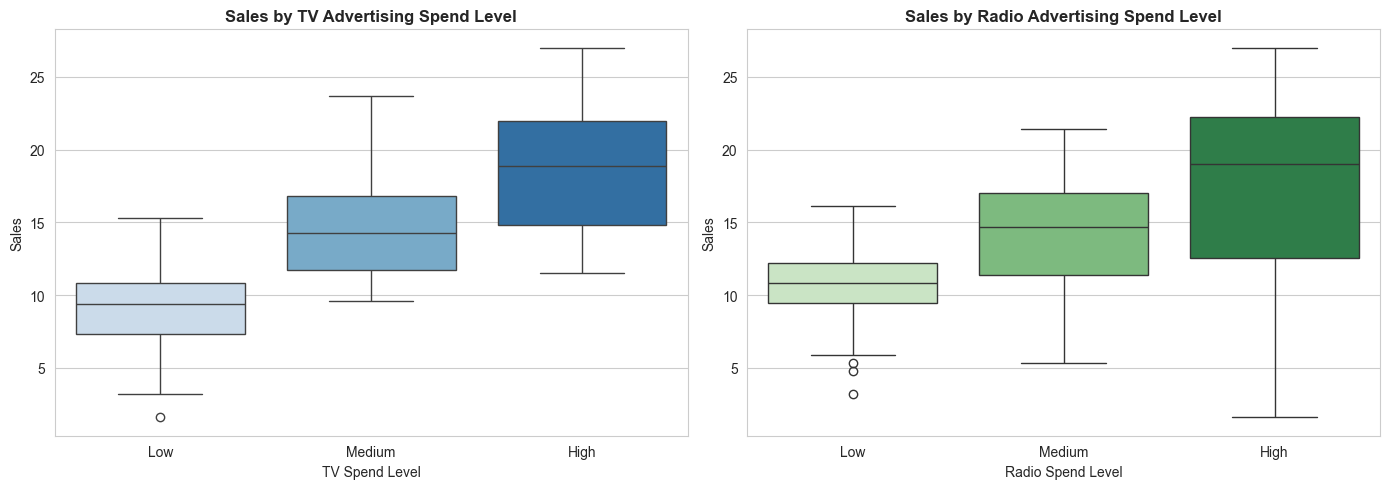

In [11]:
# Categorize advertising spend levels and analyze impact on sales
advert['TV_Category'] = pd.qcut(advert['TV'], q=3, labels=['Low', 'Medium', 'High'])
advert['Radio_Category'] = pd.qcut(advert['Radio'], q=3, labels=['Low', 'Medium', 'High'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='TV_Category', y='Sales', data=advert, palette="Blues", ax=axes[0])
axes[0].set_title("Sales by TV Advertising Spend Level", fontweight='bold')
axes[0].set_xlabel("TV Spend Level")
axes[0].set_ylabel("Sales")

sns.boxplot(x='Radio_Category', y='Sales', data=advert, palette="Greens", ax=axes[1])
axes[1].set_title("Sales by Radio Advertising Spend Level", fontweight='bold')
axes[1].set_xlabel("Radio Spend Level")
axes[1].set_ylabel("Sales")

plt.tight_layout()
plt.show()

## Step 4: Model Training & Hyperparameter Tuning

### Data Preparation

In [12]:
# Prepare data for modeling - remove categorical columns added for analysis
X = advert[['TV', 'Radio', 'Newspaper']]
y = advert['Sales']

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Features: {X.shape[1]} ({list(X.columns)})")

Training set size: 140 samples
Testing set size: 60 samples
Features: 3 (['TV', 'Radio', 'Newspaper'])


### Baseline Model Training

In [13]:
# Train baseline Random Forest model with feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize baseline model
baseline_model = RandomForestRegressor(n_estimators=100, random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# Evaluate baseline
y_pred_baseline = baseline_model.predict(X_test_scaled)
baseline_r2 = baseline_model.score(X_test_scaled, y_test)
baseline_rmse = np.sqrt(mse(y_test, y_pred_baseline))

print("=" * 70)
print("BASELINE MODEL PERFORMANCE (Random Forest - 100 estimators)")
print("=" * 70)
print(f"Training Accuracy: {baseline_model.score(X_train_scaled, y_train):.4f}")
print(f"Testing Accuracy (R²): {baseline_r2:.4f}")
print(f"RMSE: {baseline_rmse:.4f}")
print("=" * 70)

BASELINE MODEL PERFORMANCE (Random Forest - 100 estimators)
Training Accuracy: 0.9958
Testing Accuracy (R²): 0.9830
RMSE: 0.6807


In [14]:
### Hyperparameter Tuning with GridSearchCV

# Perform hyperparameter tuning using GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Starting hyperparameter tuning...")
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), 
                          param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

print("\n" + "=" * 70)
print("HYPERPARAMETER TUNING RESULTS")
print("=" * 70)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation R² score: {grid_search.best_score_:.4f}")

# Evaluate tuned model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)
tuned_r2 = best_model.score(X_test_scaled, y_test)
tuned_rmse = np.sqrt(mse(y_test, y_pred_tuned))

print(f"\nTuned Model Performance on Test Set:")
print(f"R² Score: {tuned_r2:.4f}")
print(f"RMSE: {tuned_rmse:.4f}")
print(f"Improvement: {((tuned_r2 - baseline_r2) / baseline_r2 * 100):.2f}%")
print("=" * 70)

## Step 5: Feature Engineering

In [16]:
# Create interaction features to capture synergies between advertising channels
X_train_eng = X_train.copy()
X_test_eng = X_test.copy()

# Generate interaction terms
X_train_eng['TV_Radio'] = X_train_eng['TV'] * X_train_eng['Radio']
X_train_eng['TV_Newspaper'] = X_train_eng['TV'] * X_train_eng['Newspaper']
X_train_eng['Radio_Newspaper'] = X_train_eng['Radio'] * X_train_eng['Newspaper']
X_train_eng['All_Channels'] = X_train_eng['TV'] * X_train_eng['Radio'] * X_train_eng['Newspaper']

X_test_eng['TV_Radio'] = X_test_eng['TV'] * X_test_eng['Radio']
X_test_eng['TV_Newspaper'] = X_test_eng['TV'] * X_test_eng['Newspaper']
X_test_eng['Radio_Newspaper'] = X_test_eng['Radio'] * X_test_eng['Newspaper']
X_test_eng['All_Channels'] = X_test_eng['TV'] * X_test_eng['Radio'] * X_test_eng['Newspaper']

# Scale engineered features
X_train_eng_scaled = scaler.fit_transform(X_train_eng)
X_test_eng_scaled = scaler.transform(X_test_eng)

# Train model with engineered features
model_eng = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)
model_eng.fit(X_train_eng_scaled, y_train)

# Evaluate engineered model
y_pred_eng = model_eng.predict(X_test_eng_scaled)
eng_r2 = model_eng.score(X_test_eng_scaled, y_test)
eng_rmse = np.sqrt(mse(y_test, y_pred_eng))

print("=" * 70)
print("FEATURE ENGINEERING RESULTS")
print("=" * 70)
print(f"Original features: {X_train.shape[1]}")
print(f"Engineered features: {X_train_eng.shape[1]}")
print(f"New interaction terms added: {X_train_eng.shape[1] - X_train.shape[1]}")
print(f"\nEngineered Model Performance:")
print(f"R² Score: {eng_r2:.4f}")
print(f"RMSE: {eng_rmse:.4f}")
print(f"Improvement vs Baseline: {((eng_r2 - baseline_r2) / baseline_r2 * 100):.2f}%")
print("=" * 70)

FEATURE ENGINEERING RESULTS
Original features: 3
Engineered features: 7
New interaction terms added: 4

Engineered Model Performance:
R² Score: 0.9898
RMSE: 0.5274
Improvement vs Baseline: 0.69%


## Step 6: Model Comparison & Evaluation

MODEL COMPARISON (Using Original Features)
Linear Regression    | R²: 0.8609 | RMSE: 1.9485
Ridge Regression     | R²: 0.8608 | RMSE: 1.9494
Random Forest        | R²: 0.9832 | RMSE: 0.6769
Gradient Boosting    | R²: 0.9780 | RMSE: 0.7742

Model Comparison Summary:
                   R² Score      RMSE
Random Forest      0.983220  0.676890
Gradient Boosting  0.978048  0.774200
Linear Regression  0.860947  1.948537
Ridge Regression   0.860823  1.949406


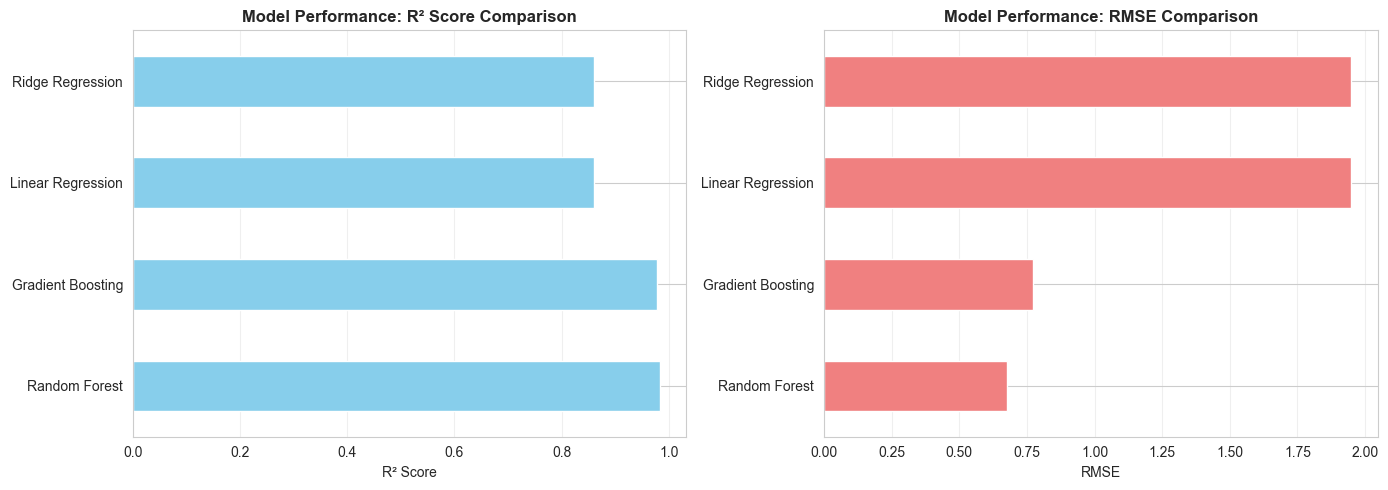

In [17]:
# Compare performance across multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = {}

print("=" * 70)
print("MODEL COMPARISON (Using Original Features)")
print("=" * 70)

for model_name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    y_pred_model = model.predict(X_test_scaled)
    r2 = model.score(X_test_scaled, y_test)
    rmse = np.sqrt(mse(y_test, y_pred_model))
    
    results[model_name] = {'R² Score': r2, 'RMSE': rmse}
    print(f"{model_name:20s} | R²: {r2:.4f} | RMSE: {rmse:.4f}")

print("=" * 70)

# Create comparison dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R² Score', ascending=False)

print("\nModel Comparison Summary:")
print(results_df)

# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_df['R² Score'].plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Model Performance: R² Score Comparison', fontweight='bold')
axes[0].set_xlabel('R² Score')
axes[0].grid(axis='x', alpha=0.3)

results_df['RMSE'].plot(kind='barh', ax=axes[1], color='lightcoral')
axes[1].set_title('Model Performance: RMSE Comparison', fontweight='bold')
axes[1].set_xlabel('RMSE')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


FINAL RESULTS & RECOMMENDATIONS

 Best Model: Random Forest
   R² Score: 0.9832
   RMSE: 0.6769

Interpretation:
   - The model explains 98.32% of sales variance
   - Average prediction error: $0.68K

Feature Importance (Random Forest):
  Feature  Importance
       TV    0.635765
    Radio    0.353495
Newspaper    0.010740


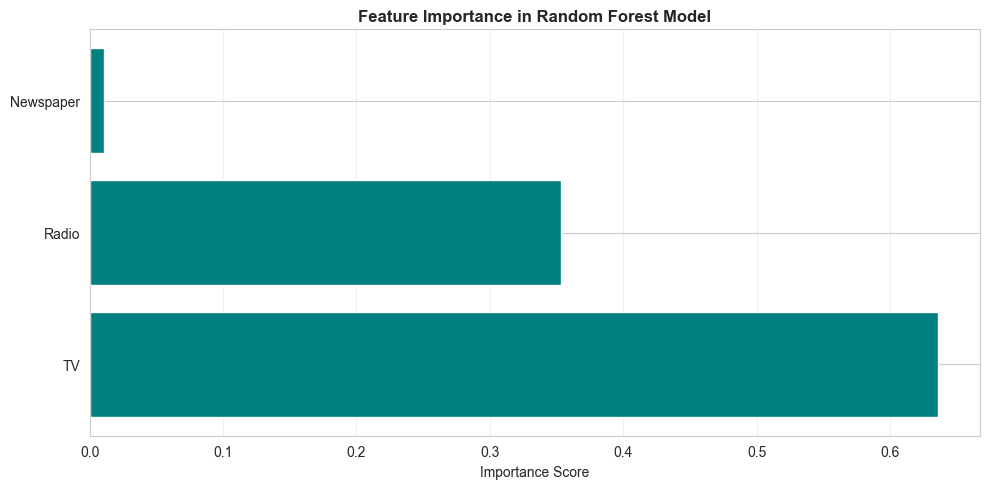

In [19]:
### Summary: Best Model Performance Analysis

# Get best performing model
best_model_name = results_df.index[0]
best_r2 = results_df.iloc[0]['R² Score']
best_rmse = results_df.iloc[0]['RMSE']

print("\n" + "=" * 70)
print("FINAL RESULTS & RECOMMENDATIONS")
print("=" * 70)
print(f"\n Best Model: {best_model_name}")
print(f"   R² Score: {best_r2:.4f}")
print(f"   RMSE: {best_rmse:.4f}")
print(f"\nInterpretation:")
print(f"   - The model explains {best_r2*100:.2f}% of sales variance")
print(f"   - Average prediction error: ${best_rmse:.2f}K")

# Feature importance for tree-based models
print(f"\n" + "=" * 70)
print("Feature Importance (Random Forest):")
print("=" * 70)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)
rf_model.fit(X_train_scaled, y_train)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 5))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='teal')
plt.title('Feature Importance in Random Forest Model', fontweight='bold', fontsize=12)
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)